In [4]:
# Google Colab – mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
BASE = "/content/drive/MyDrive/Datasets/IEOR4578_Forecasting"
!cp "{BASE}/master_long_hourly_train_2012_2013.csv"        /content/
!cp "{BASE}/master_long_hourly_validation_2014_01_04.csv"  /content/
!cp "{BASE}/master_long_hourly_test_2014_05_12.csv"        /content/
!cp "{BASE}/user_cluster_mapping.csv"                      /content/

In [6]:
!pip install -q statsforecast

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_PATH   = "/content/master_long_hourly_train_2012_2013.csv"
VAL_PATH     = "/content/master_long_hourly_validation_2014_01_04.csv"
TEST_PATH    = "/content/master_long_hourly_test_2014_05_12.csv"
CLUSTER_PATH = "/content/user_cluster_mapping.csv"

SEASON_LENGTH  = 24    # daily seasonality (hourly data)
LOOKBACK_HOURS = 672   # 4-week look-back window

# Fixed test-period boundaries (1 464 hours each)
TEST_PERIODS = {
    "Period 1": ("2014-05-01 00:00:00", "2014-06-30 23:00:00"),
    "Period 2": ("2014-07-01 00:00:00", "2014-08-30 23:00:00"),
    "Period 3": ("2014-08-31 00:00:00", "2014-10-31 23:00:00"),
    "Period 4": ("2014-11-01 00:00:00", "2014-12-31 23:00:00"),
}

In [8]:
import warnings, joblib
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

## 1. Load Data & Cluster Mapping

In [9]:
def load_split(path):
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df.rename(columns={"client_id": "unique_id", "timestamp": "ds"})
    return df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

def apply_lookback(df, hours):
    """Keep only the last `hours` rows per client."""
    return (df.groupby("unique_id", group_keys=False)
              .tail(hours)
              .reset_index(drop=True))

train = load_split(TRAIN_PATH)
val   = load_split(VAL_PATH)
test  = load_split(TEST_PATH)

cluster_map = pd.read_csv(CLUSTER_PATH).rename(columns={"user_id": "unique_id"})

print(f"train : {train.shape}  {train['ds'].min()} to {train['ds'].max()}")
print(f"val   : {val.shape}    {val['ds'].min()} to {val['ds'].max()}")
print(f"test  : {test.shape}   {test['ds'].min()} to {test['ds'].max()}")
print()
print('Cluster summary:')
print(cluster_map.groupby(["cluster_id","cluster_name"])["unique_id"].count().rename("n_users").to_string())

train : (2721888, 3)  2012-01-01 00:00:00 to 2013-12-31 23:00:00
val   : (445536, 3)    2014-01-01 00:00:00 to 2014-04-30 23:00:00
test  : (913536, 3)   2014-05-01 00:00:00 to 2014-12-31 23:00:00

Cluster summary:
cluster_id  cluster_name                
-1          outlier_irregular_profile        8
 0          high_load_daytime_mixed_week    84
 1          low_load_daytime_mixed_week     64


## 2. Metric Utilities

In [10]:
def mape(y, yhat):
    """MAPE on 0-100 scale; skips zero / NaN actuals."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    mask = (np.abs(y) > 1e-8) & np.isfinite(y) & np.isfinite(yhat)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])) * 100)

def ape_per_user(eval_df, model_col):
    """Return DataFrame[unique_id, mape] with per-user mean MAPE."""
    rows = []
    for uid, g in eval_df.groupby("unique_id"):
        rows.append({'unique_id': uid, 'mape': mape(g['y'].values, g[model_col].values)})
    return pd.DataFrame(rows)

def mape_table(eval_df, model_cols, group_col=None):
    rows = []
    groups = sorted(eval_df[group_col].unique()) if group_col else [None]
    for grp in groups:
        sub = eval_df[eval_df[group_col] == grp] if group_col else eval_df
        row = {group_col: grp} if group_col else {}
        for col in model_cols:
            row[col] = round(mape(sub['y'].values, sub[col].values), 3)
        rows.append(row)
    return pd.DataFrame(rows)

## 3. Phase 1 — Validation: Per-Cluster Model Training & Selection

Train **AutoARIMA** per cluster on the training data,  
then evaluate on the validation set.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Train per-cluster models on train set  →  evaluate on val set
# ─────────────────────────────────────────────────────────────────────────────
train_lb    = apply_lookback(train, LOOKBACK_HOURS)
val_h       = val['ds'].nunique()
cluster_ids = sorted(cluster_map['cluster_id'].unique())

val_preds_list = []
sf_val_models  = {}   # cluster_id -> fitted StatsForecast

for cid in cluster_ids:
    meta  = cluster_map[cluster_map['cluster_id'] == cid]
    users = meta['unique_id'].tolist()
    cname = meta['cluster_name'].iloc[0]
    print(f'\n[Cluster {cid}] {cname}  ({len(users)} users) -- training ...')

    c_train = train_lb[train_lb['unique_id'].isin(users)][['unique_id','ds','y']]

    sf = StatsForecast(
        models=[
            AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True),
        ],
        freq='h', n_jobs=-1,
    )
    sf.fit(c_train)
    sf_val_models[cid] = sf

    preds = sf.predict(h=val_h)
    val_preds_list.append(preds)
    print('  done')

val_preds = pd.concat(val_preds_list, ignore_index=True)
val_eval  = (val[['unique_id','ds','y']]
             .merge(val_preds, on=['unique_id','ds'])
             .merge(cluster_map[['unique_id','cluster_id','cluster_name']], on='unique_id'))

MODEL_COLS = ['AutoARIMA']
print(f'\nModel columns: {MODEL_COLS}')


[Cluster -1] outlier_irregular_profile  (8 users) -- training ...
  done

[Cluster 0] high_load_daytime_mixed_week  (84 users) -- training ...
  done

[Cluster 1] low_load_daytime_mixed_week  (64 users) -- training ...
  done

Model columns: ['AutoARIMA']


In [12]:
print('=' * 60)
print('  VALIDATION MAPE (0-100 scale) — Model Selection')
print('=' * 60)

print('\n-- Overall --')
val_overall = mape_table(val_eval, MODEL_COLS)
print(val_overall.to_string(index=False))

print('\n-- By Cluster --')
val_cluster = mape_table(val_eval, MODEL_COLS, group_col='cluster_name')
print(val_cluster.to_string(index=False))

  VALIDATION MAPE (0-100 scale) — Model Selection

-- Overall --
 AutoARIMA
    16.044

-- By Cluster --
                cluster_name  AutoARIMA
high_load_daytime_mixed_week     14.382
 low_load_daytime_mixed_week     12.824
   outlier_irregular_profile     61.972


## 4. Phase 2 — Test Evaluation: Retrain on Train+Val, Predict Test Set

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Retrain on train+val  ->  predict full test set
# ─────────────────────────────────────────────────────────────────────────────
train_val    = pd.concat([train, val], ignore_index=True).sort_values(['unique_id','ds'])
train_val_lb = apply_lookback(train_val, LOOKBACK_HOURS)
test_h       = test['ds'].nunique()

test_preds_list = []
sf_test_models  = {}   # cluster_id -> final fitted StatsForecast

for cid in cluster_ids:
    meta  = cluster_map[cluster_map['cluster_id'] == cid]
    users = meta['unique_id'].tolist()
    cname = meta['cluster_name'].iloc[0]
    print(f'\n[Cluster {cid}] {cname}  ({len(users)} users) -- retraining on train+val ...')

    c_tv = train_val_lb[train_val_lb['unique_id'].isin(users)][['unique_id','ds','y']]

    sf = StatsForecast(
        models=[
            AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True),
        ],
        freq='h', n_jobs=-1,
    )
    sf.fit(c_tv)
    sf_test_models[cid] = sf

    preds = sf.predict(h=test_h)
    test_preds_list.append(preds)
    print('  done')

test_preds = pd.concat(test_preds_list, ignore_index=True)
test_eval  = (test[['unique_id','ds','y']]
              .merge(test_preds, on=['unique_id','ds'])
              .merge(cluster_map[['unique_id','cluster_id','cluster_name']], on='unique_id'))

MODEL_COLS = ['AutoARIMA']
print(f'\nTest eval shape: {test_eval.shape}')
print(test_eval.head(3))


[Cluster -1] outlier_irregular_profile  (8 users) -- retraining on train+val ...
  done

[Cluster 0] high_load_daytime_mixed_week  (84 users) -- retraining on train+val ...
  done

[Cluster 1] low_load_daytime_mixed_week  (64 users) -- retraining on train+val ...
  done

Test eval shape: (909792, 6)
  unique_id                  ds         y   AutoARIMA  cluster_id  \
0    MT_124 2014-05-01 00:00:00  362.4402  340.181344          -1   
1    MT_124 2014-05-01 01:00:00  332.5359  334.190728          -1   
2    MT_124 2014-05-01 02:00:00  332.5359  267.266554          -1   

                cluster_name  
0  outlier_irregular_profile  
1  outlier_irregular_profile  
2  outlier_irregular_profile  


In [14]:
# Tag each row with its test period
def assign_period(ts_str):
    for pname, (start, end) in TEST_PERIODS.items():
        if start <= ts_str <= end:
            return pname
    return 'Other'

test_eval['period'] = test_eval['ds'].astype(str).apply(assign_period)
print(test_eval['period'].value_counts().sort_index())

period
Period 1    228384
Period 2    228384
Period 3    228384
Period 4    224640
Name: count, dtype: int64


## 5. Results Summary

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# [1] Overall Test MAPE
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('  [1] OVERALL TEST MAPE (0-100 scale)')
print('=' * 60)
overall_df = mape_table(test_eval, MODEL_COLS)
overall_df.insert(0, 'Scope', 'Overall (test set)')
print(overall_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# [2] Test MAPE by Period
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('  [2] TEST MAPE BY PERIOD (0-100 scale)')
print('=' * 70)
period_rows = []
for pname, (start, end) in TEST_PERIODS.items():
    sub = test_eval[test_eval['period'] == pname]
    row = {'Period': pname, 'Date Range': f'{start[:10]} to {end[:10]}', 'N_obs': len(sub)}
    for col in MODEL_COLS:
        row[col] = round(mape(sub['y'].values, sub[col].values), 3)
    period_rows.append(row)
period_df = pd.DataFrame(period_rows)
print(period_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# [3] Test MAPE by Cluster
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('  [3] TEST MAPE BY CLUSTER (0-100 scale)')
print('=' * 70)
cluster_rows = []
for cid in cluster_ids:
    meta  = cluster_map[cluster_map['cluster_id'] == cid]
    cname = meta['cluster_name'].iloc[0]
    sub   = test_eval[test_eval['cluster_id'] == cid]
    row   = {'Cluster ID': cid, 'Cluster Name': cname, 'N_users': len(meta)}
    for col in MODEL_COLS:
        row[col] = round(mape(sub['y'].values, sub[col].values), 3)
    cluster_rows.append(row)
cluster_df = pd.DataFrame(cluster_rows)
print(cluster_df.to_string(index=False))

  [1] OVERALL TEST MAPE (0-100 scale)
             Scope  AutoARIMA
Overall (test set)     18.726

  [2] TEST MAPE BY PERIOD (0-100 scale)
  Period               Date Range  N_obs  AutoARIMA
Period 1 2014-05-01 to 2014-06-30 228384     11.506
Period 2 2014-07-01 to 2014-08-30 228384     17.815
Period 3 2014-08-31 to 2014-10-31 228384     20.234
Period 4 2014-11-01 to 2014-12-31 224640     25.485

  [3] TEST MAPE BY CLUSTER (0-100 scale)
 Cluster ID                 Cluster Name  N_users  AutoARIMA
         -1    outlier_irregular_profile        8     38.857
          0 high_load_daytime_mixed_week       84     14.552
          1  low_load_daytime_mixed_week       64     21.829


## 6. Error Distribution — Box Plots

Each box shows the **per-user MAPE** distribution across users.  
- **Box**: IQR (25th–75th percentile)  
- **Red line**: median  
- **Whiskers**: 1.5 × IQR  
- **Dots**: individual outlier users

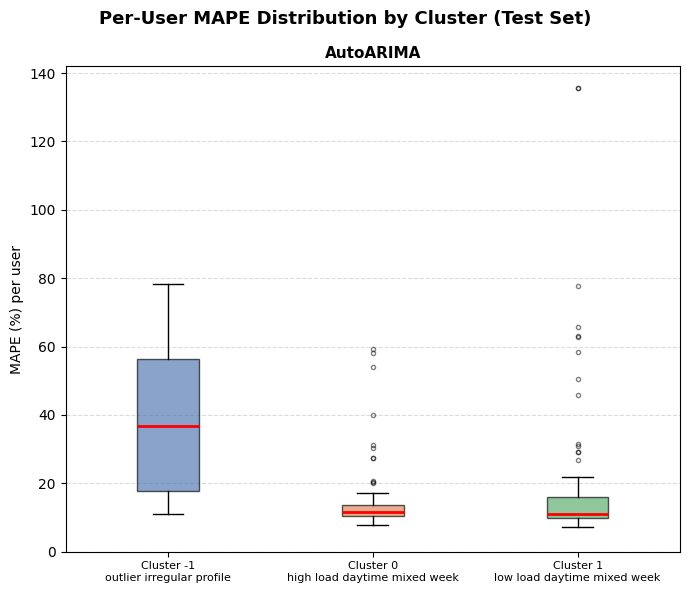

Saved: boxplot_by_cluster.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# BOX PLOT 1 – Per-user MAPE by Cluster
# ─────────────────────────────────────────────────────────────────────────────
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, len(MODEL_COLS), figsize=(7 * len(MODEL_COLS), 6))
if len(MODEL_COLS) == 1:
    axes = [axes]
fig.suptitle('Per-User MAPE Distribution by Cluster (Test Set)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, MODEL_COLS):
    data, labels = [], []
    for i, cid in enumerate(cluster_ids):
        meta  = cluster_map[cluster_map['cluster_id'] == cid]
        users = meta['unique_id'].tolist()
        cname = meta['cluster_name'].iloc[0].replace('_', ' ')
        sub   = test_eval[test_eval['unique_id'].isin(users)]
        per_u = ape_per_user(sub, col)['mape'].dropna().values
        data.append(per_u)
        labels.append(f'Cluster {cid}\n{cname}')

    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('MAPE (%) per user')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.45)

plt.tight_layout()
plt.savefig('boxplot_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boxplot_by_cluster.png')

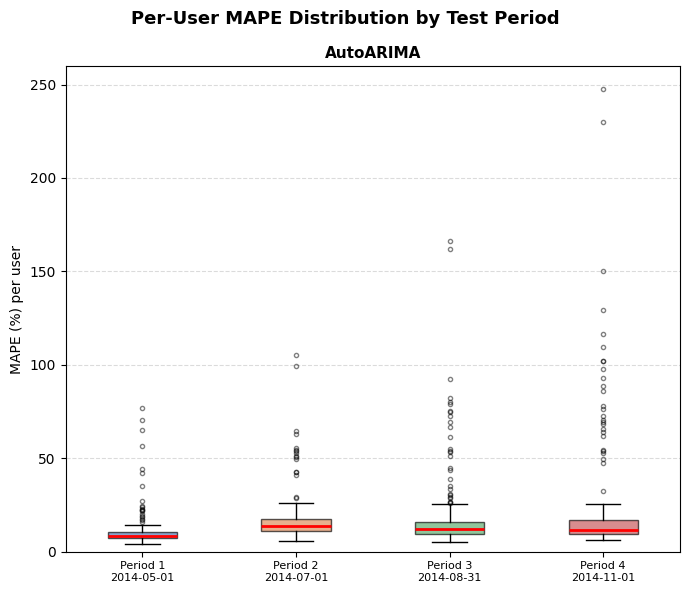

Saved: boxplot_by_period.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# BOX PLOT 2 – Per-user MAPE by Test Period
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODEL_COLS), figsize=(7 * len(MODEL_COLS), 6))
if len(MODEL_COLS) == 1:
    axes = [axes]
fig.suptitle('Per-User MAPE Distribution by Test Period', fontsize=13, fontweight='bold')

for ax, col in zip(axes, MODEL_COLS):
    data, labels = [], []
    for pname, (start, end) in TEST_PERIODS.items():
        sub   = test_eval[test_eval['period'] == pname]
        per_u = ape_per_user(sub, col)['mape'].dropna().values
        data.append(per_u)
        labels.append(f'{pname}\n{start[:10]}')

    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('MAPE (%) per user')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.45)

plt.tight_layout()
plt.savefig('boxplot_by_period.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: boxplot_by_period.png')

## 7. Save Final Cluster Models

In [18]:
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

for cid, sf in sf_test_models.items():
    cname = cluster_map[cluster_map['cluster_id'] == cid]['cluster_name'].iloc[0]
    path  = MODEL_DIR / f'sf_cluster_{cid}_{cname}.joblib'
    joblib.dump(sf, path)
    print(f'Saved: {path}')

Saved: models/sf_cluster_-1_outlier_irregular_profile.joblib
Saved: models/sf_cluster_0_high_load_daytime_mixed_week.joblib
Saved: models/sf_cluster_1_low_load_daytime_mixed_week.joblib
